In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def run_statistical_suite(file_path, market_name):
    print(f"Running Statistical Suite for {market_name}...")
    
    # 1. Load and Resample to Daily
    df = pd.read_csv(file_path)
    df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
    df.set_index('DateTime', inplace=True)
    df_daily = df['Close'].resample('D').last().dropna()
    
    # 2. Calculate Log Prices and Daily Returns
    log_p = np.log(df_daily.values)
    daily_returns = pd.Series(np.diff(log_p))
    
    # --- TEST 1: Variance Ratio (Existence & Type) ---
    def calculate_vr(series, k):
        n = len(series)
        var_1 = np.var(np.diff(series), ddof=1)
        var_k = np.var(series[k:] - series[:-k], ddof=1)
        return var_k / (k * var_1)

    vr_lags = [5, 21, 63, 126, 252] # Week, Month, Quarter, Half-Year, Year
    vr_results = [calculate_vr(log_p, k) for k in vr_lags]

    # --- TEST 2: Push-Response (Location & Timing) ---
    pr_lags = range(1, 253)
    pr_results = [daily_returns.corr(daily_returns.shift(i)) for i in pr_lags]

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Variance Ratio Plot
    ax1.plot(vr_lags, vr_results, marker='o', color='blue', label='Variance Ratio')
    ax1.axhline(1, color='red', linestyle='--', label='Random Walk')
    ax1.set_title(f'Variance Ratio Test (1-Year Scale): {market_name}')
    ax1.set_ylabel('VR Ratio (>1: TF, <1: MR)')
    ax1.legend()
    
    # Push-Response Plot
    ax2.bar(pr_lags, pr_results, color='green', alpha=0.6)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title(f'Push-Response (Autocorrelation): {market_name}')
    ax2.set_xlabel('Lag (Trading Days)')
    ax2.set_ylabel('Correlation')
    
    plt.tight_layout()
    plt.show()

    # inference 
    final_vr = vr_results[-1]
    print(f"Variance Ratio at Year scale: {final_vr:.4f}")
    
    if final_vr > 1:
        print(f"Inference: {market_name} shows significant Trend-Following at a year scale.")
    else:
        print(f"Inference: {market_name} shows Mean-Reversion at a year scale.")

Running Statistical Suite for TY (Primary)...


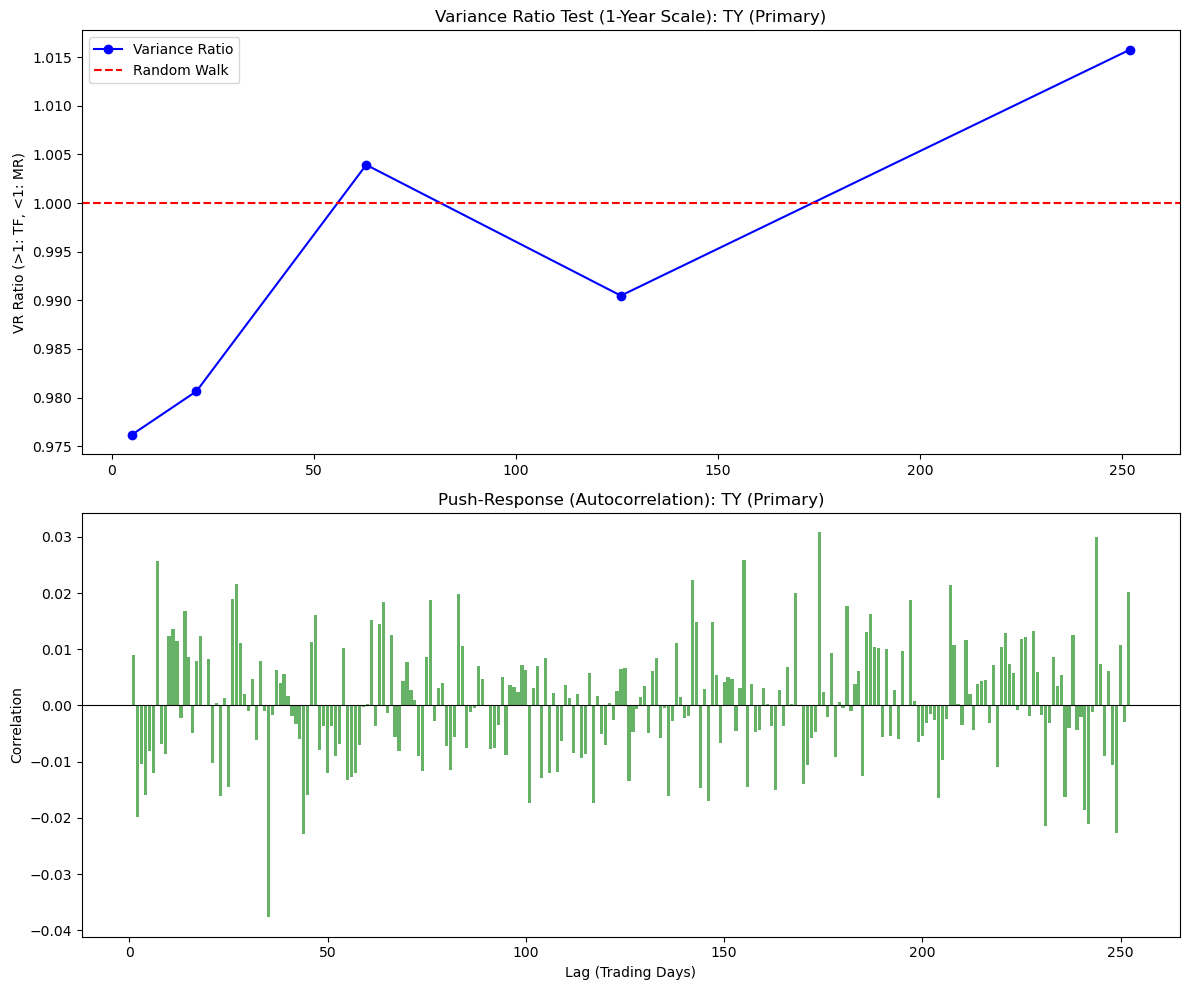

Variance Ratio at Year scale: 1.0158
Inference: TY (Primary) shows significant Trend-Following at a year scale.


In [3]:
run_statistical_suite('TY-5minHLV.csv', 'TY (Primary)')

Running Statistical Suite for Bitcoin...


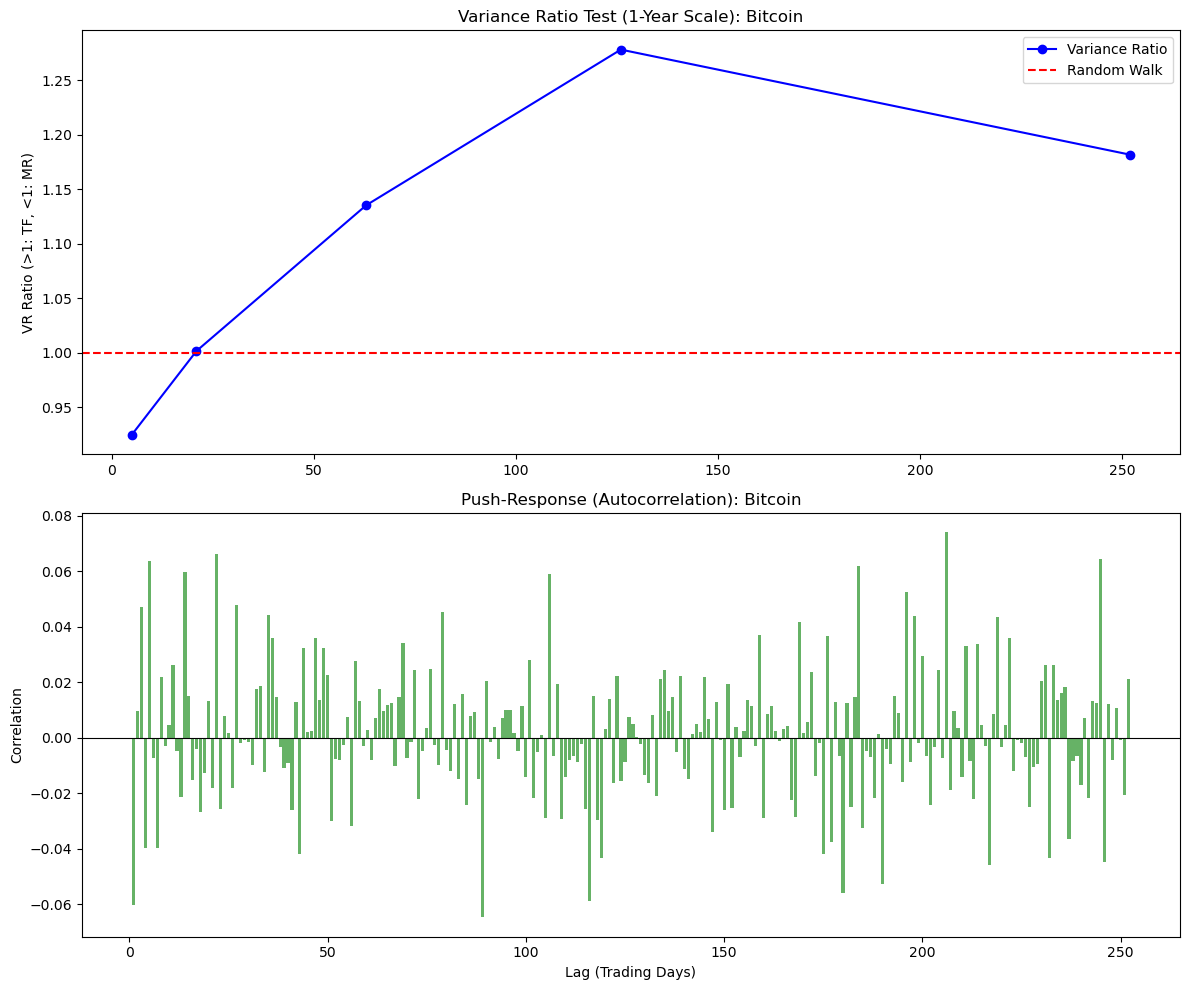

Variance Ratio at Year scale: 1.1817
Inference: Bitcoin shows significant Trend-Following at a year scale.


In [4]:
run_statistical_suite('BTC-5minHLV.csv', 'Bitcoin')